In [4]:
import os, sys, json
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, '..')

from UC1PrintingUtils import (
    VARIANTS_DEFAULT,
    load_results,
    print_results_table,
    plot_convergence,
    plot_pareto,
    plot_equity,
    plot_auc_vs_alpha,
)

FEDAVG_RESULTS  = '../02_FedAvg/results'
FEDGEN_RESULTS  = '../03_FedGen/results'
ALPHA_SWEEP     = [0.1, 0.5, 1.0, 5.0, 10.0]
SEEDS           = [42, 123, 7]
CENTRALIZED_AUC = 0.658
VARIANTS        = VARIANTS_DEFAULT

plt.rcParams.update({
    'figure.dpi':        130,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         11,
})

os.makedirs('figures', exist_ok=True)

In [5]:
all_results = {}

for data_case in ['filtered', 'unfiltered']:
    all_results[data_case] = load_results(
        FEDAVG_RESULTS, FEDGEN_RESULTS,
        ALPHA_SWEEP, SEEDS, VARIANTS,
        data_case=data_case,
    )
    print_results_table(all_results[data_case], ALPHA_SWEEP, VARIANTS, data_case)

[filtered] All 60 result files loaded successfully.

── Results summary [filtered] ──
    Case    α          Variant  Mean AUC  Std AUC  Client σ  Rounds  Final MB
filtered  0.1    FedAvg (full)    0.5771   0.0055    0.0602    20.0    165.92
filtered  0.1 FedAvg (partial)    0.6472   0.0238    0.0384    12.3      0.12
filtered  0.1    FedGen (full)    0.5822   0.0003    0.0919    11.3     95.08
filtered  0.1 FedGen (partial)    0.6458   0.0655    0.0295     8.3      0.86
filtered  0.5    FedAvg (full)    0.6438   0.0010    0.0382     6.7     55.31
filtered  0.5 FedAvg (partial)    0.6059   0.0089    0.0226     9.3      0.09
filtered  0.5    FedGen (full)    0.6438   0.0000    0.0398     8.0     67.12
filtered  0.5 FedGen (partial)    0.5981   0.0109    0.0250     9.0      0.93
filtered  1.0    FedAvg (full)    0.6150   0.0027    0.0369     7.7     63.60
filtered  1.0 FedAvg (partial)    0.6139   0.0034    0.0317    11.0      0.11
filtered  1.0    FedGen (full)    0.6190   0.0008    0.0


Figures — filtered


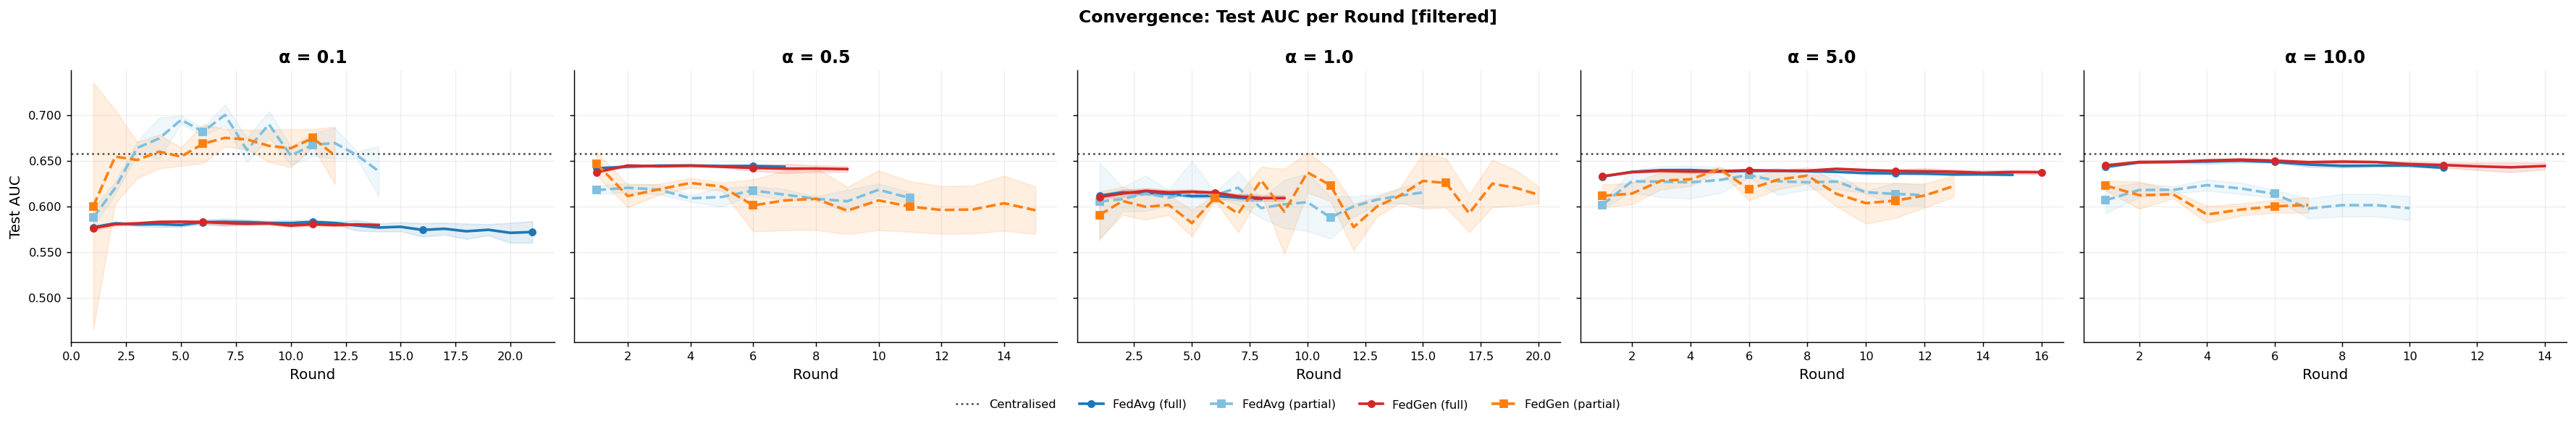

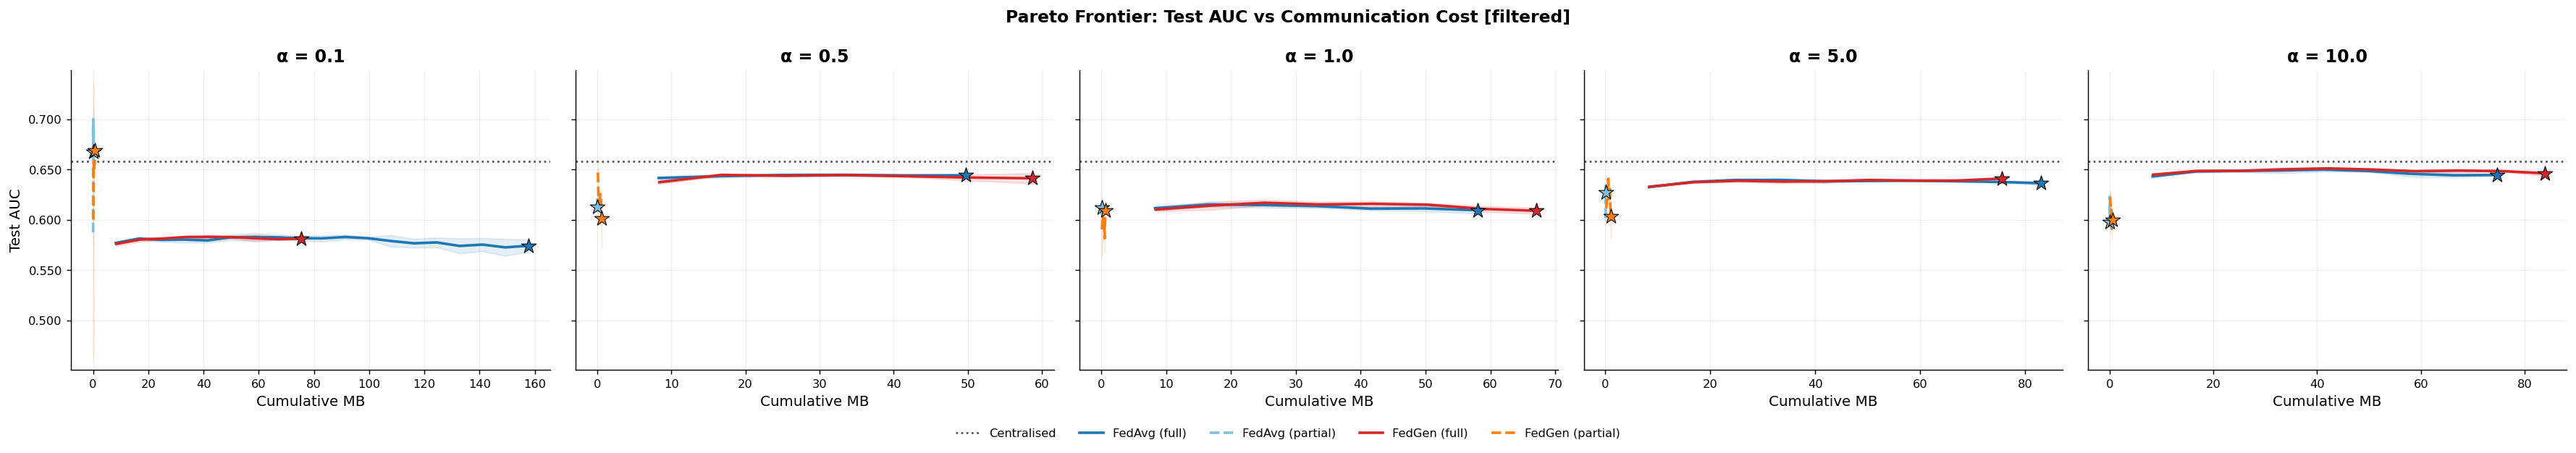

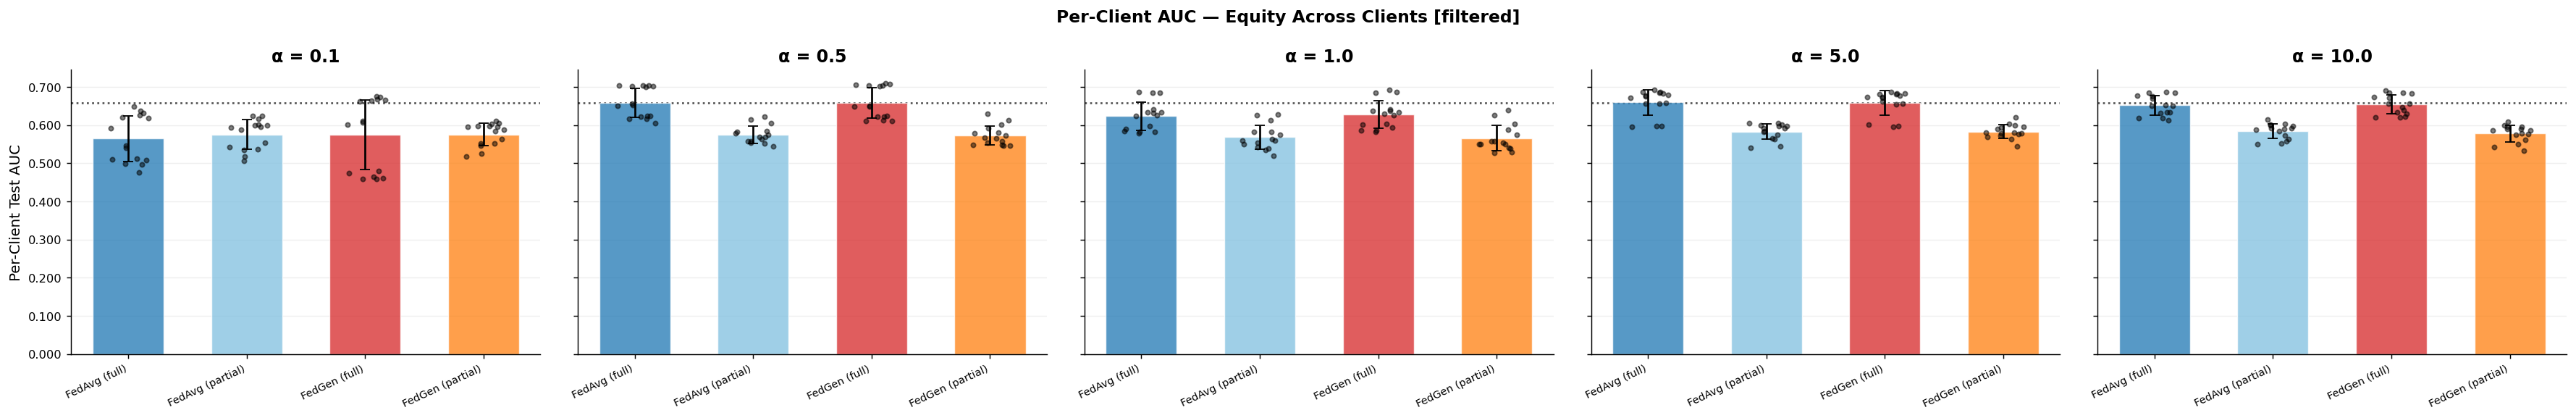

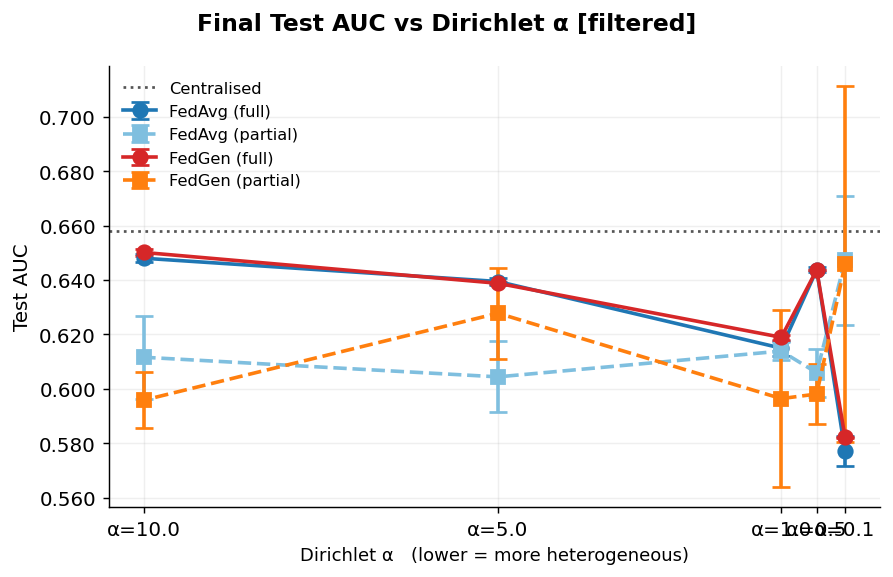


Figures — unfiltered


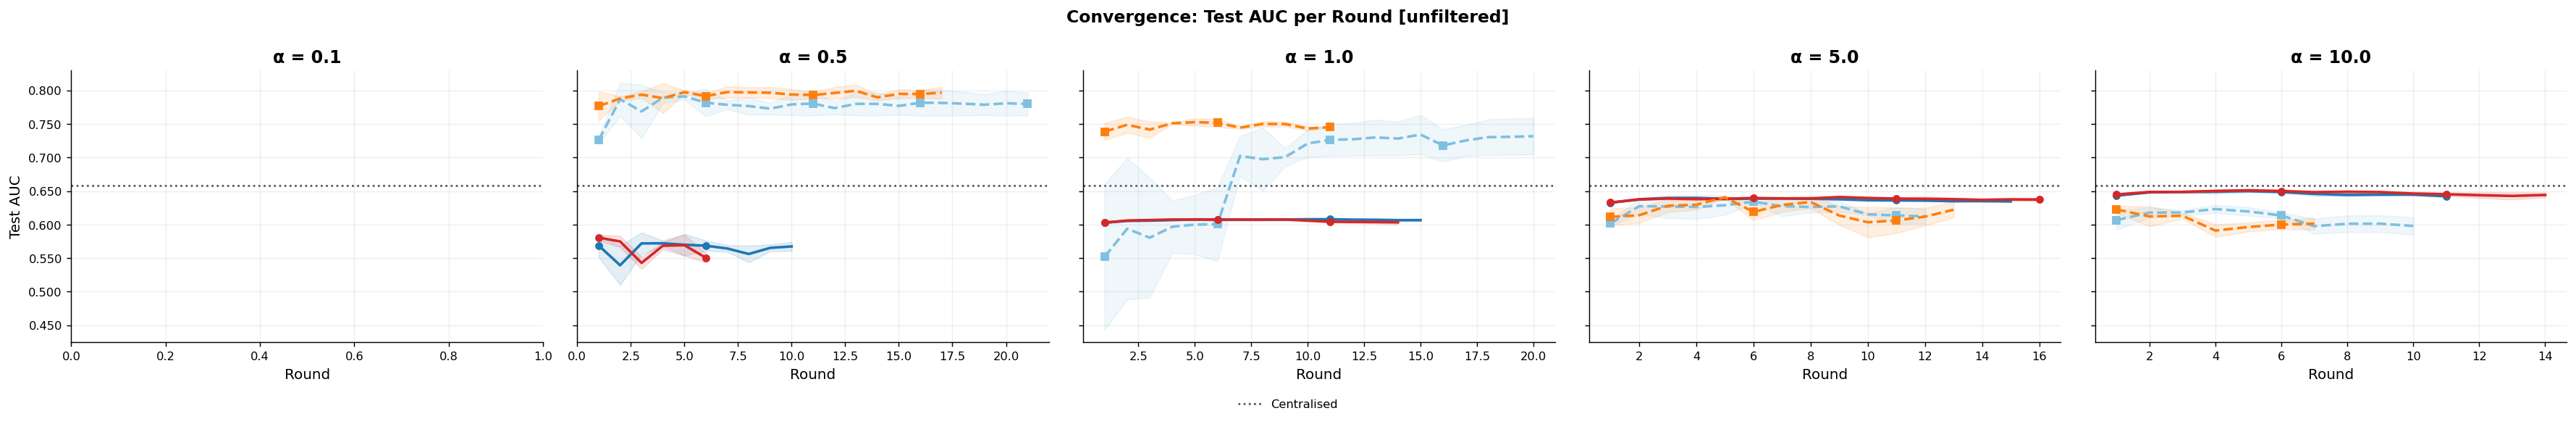

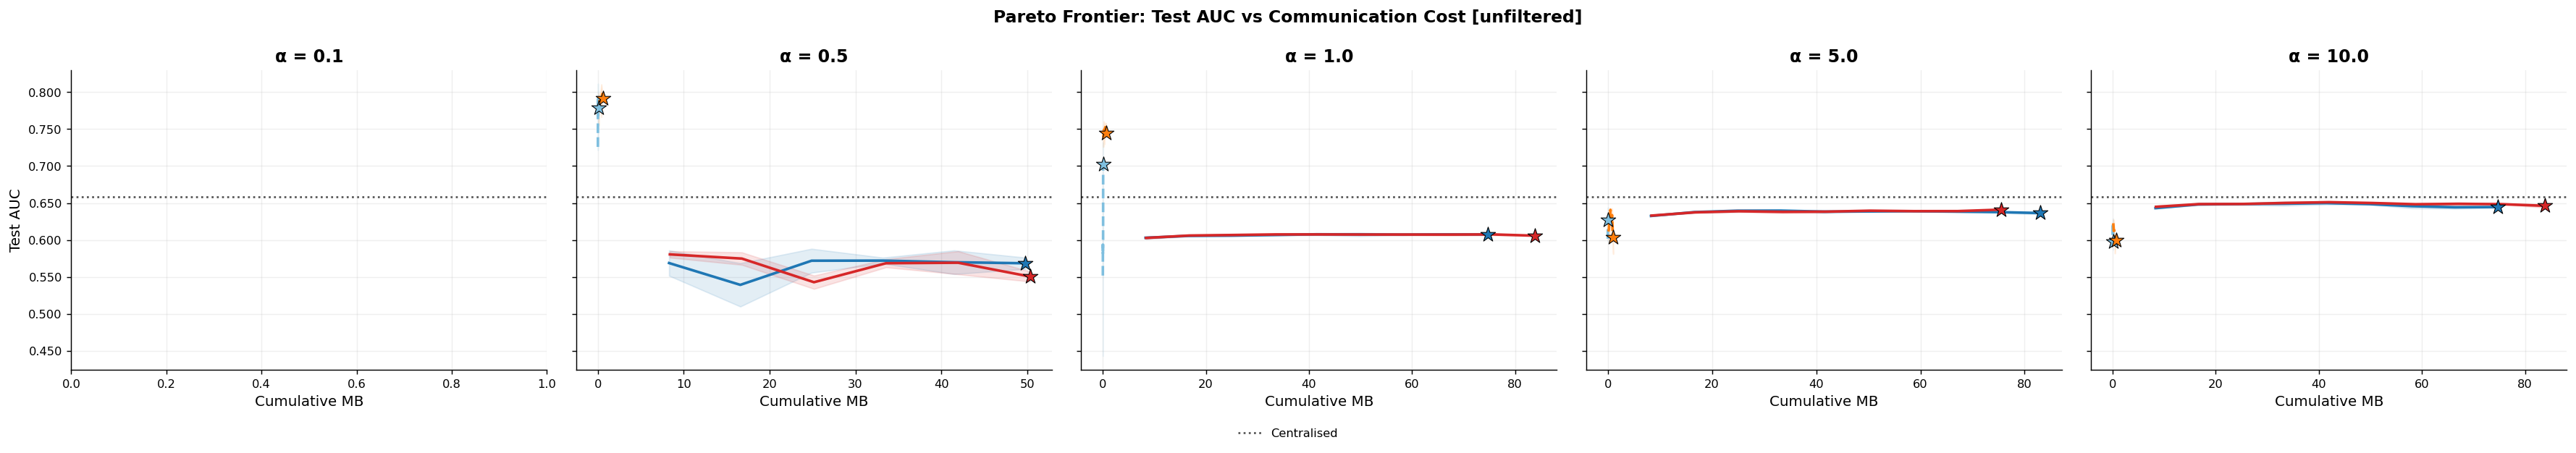

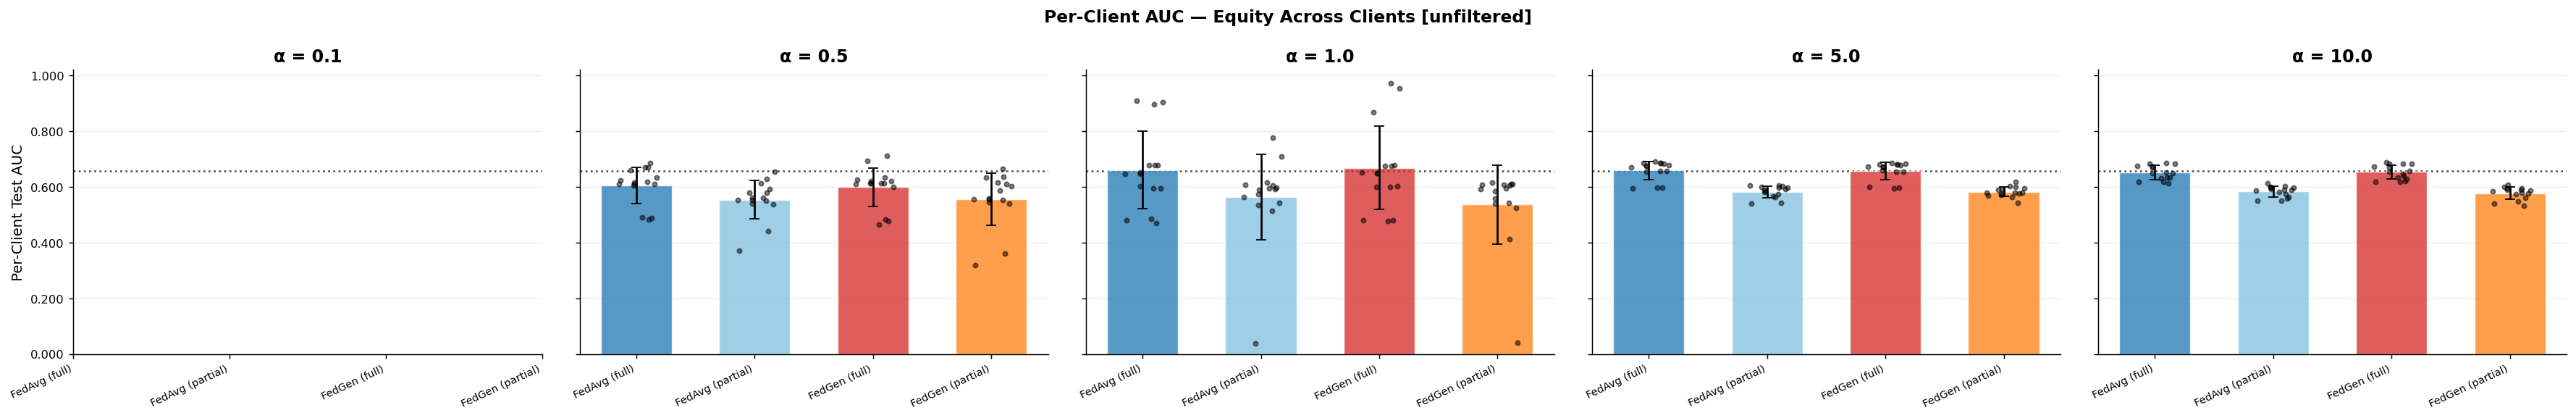

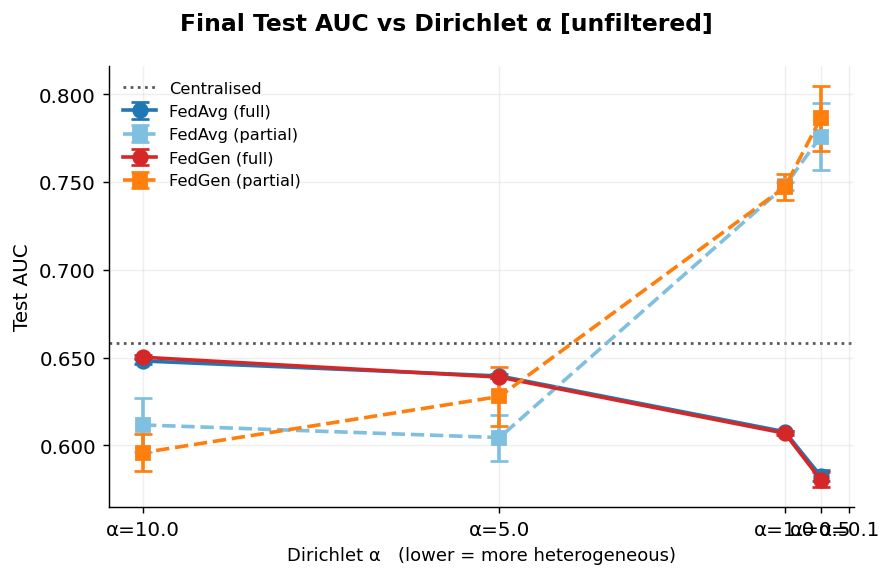

In [6]:
for data_case, results in all_results.items():
    print(f'\n{"="*60}')
    print(f'Figures — {data_case}')
    print(f'{"="*60}')

    plot_convergence(results, ALPHA_SWEEP, CENTRALIZED_AUC,
                     VARIANTS, data_case)
    plot_pareto(results, ALPHA_SWEEP, CENTRALIZED_AUC,
                VARIANTS, data_case)
    plot_equity(results, ALPHA_SWEEP, CENTRALIZED_AUC,
                VARIANTS, data_case)
    plot_auc_vs_alpha(results, ALPHA_SWEEP, CENTRALIZED_AUC,
                      VARIANTS, data_case)